# Swarm EFI IDM data product

In [1]:
import datetime
import pathlib
import os

import geospacelab.visualization.mpl.dashboards as dashboards

cwd = pathlib.Path(os.path.abspath(''))
file_dir_figure = cwd / 'figures'
file_dir_figure.mkdir(parents=True, exist_ok=True)

## Overview

Create a new figure: Figure(800x1200).


Load IGRF coefficients ...


Searching the data product "EFI_IDM" with the version "latest" on the server...
INFO: Indexing the files for the product EFI_IDM of the satellite A ...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Advanced/EFI_IDM/0301/Sat_A/2016/SW_PREL_EFIAIDM_2__20160314T000000_20160314T235959_0301.cdf')] already exists: skip downloading.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


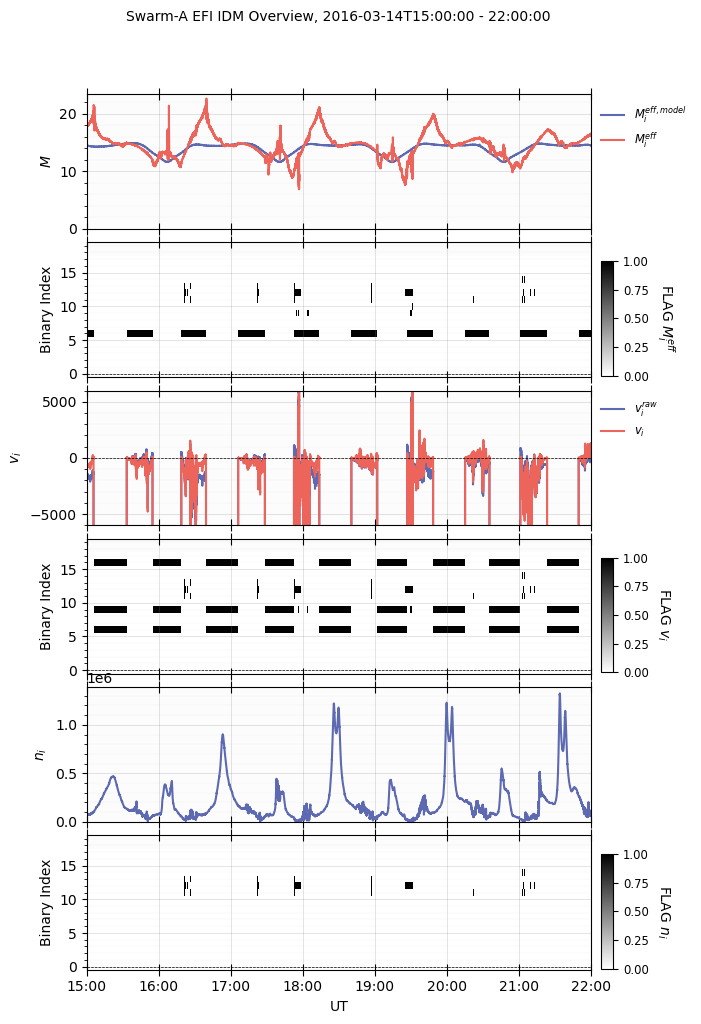

In [2]:
def test_swarm_EFI_IDM_overview():
    """Test Swarm EFI IDM data product
    
    """
    dt_fr = datetime.datetime(2016, 3, 14, 15, 0)
    dt_to = datetime.datetime(2016, 3, 14, 22, 0)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        )

    ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'advanced', 'efi_idm'], sat_id='A', add_APEX=True,)

    panel_layouts = [
        [ds['M_i_eff_model'], ds['M_i_eff']],
        [ds['FLAG_M_i_eff_BIN_AUX']],
        [ds['v_i_raw'], ds['v_i']],
        [ds['FLAG_v_i_BIN_AUX']],
        [ds['n_i'],],
        [ds['FLAG_n_i_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} EFI IDM Overview'.format(ds.sat_id), fontsize='medium', append_time=True)

    db.save_figure(file_dir=file_dir_figure, file_name='example_EFI_IDM_Swarm-{}_overview'.format(ds.sat_id), dpi=100, append_time=False)
    db.show()
test_swarm_EFI_IDM_overview()


## Zoomed-in 

Create a new figure: Figure(800x1200).
Searching the data product "EFI_IDM" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Advanced/EFI_IDM/0301/Sat_A/2016/SW_PREL_EFIAIDM_2__20160314T000000_20160314T235959_0301.cdf')] already exists: skip downloading.


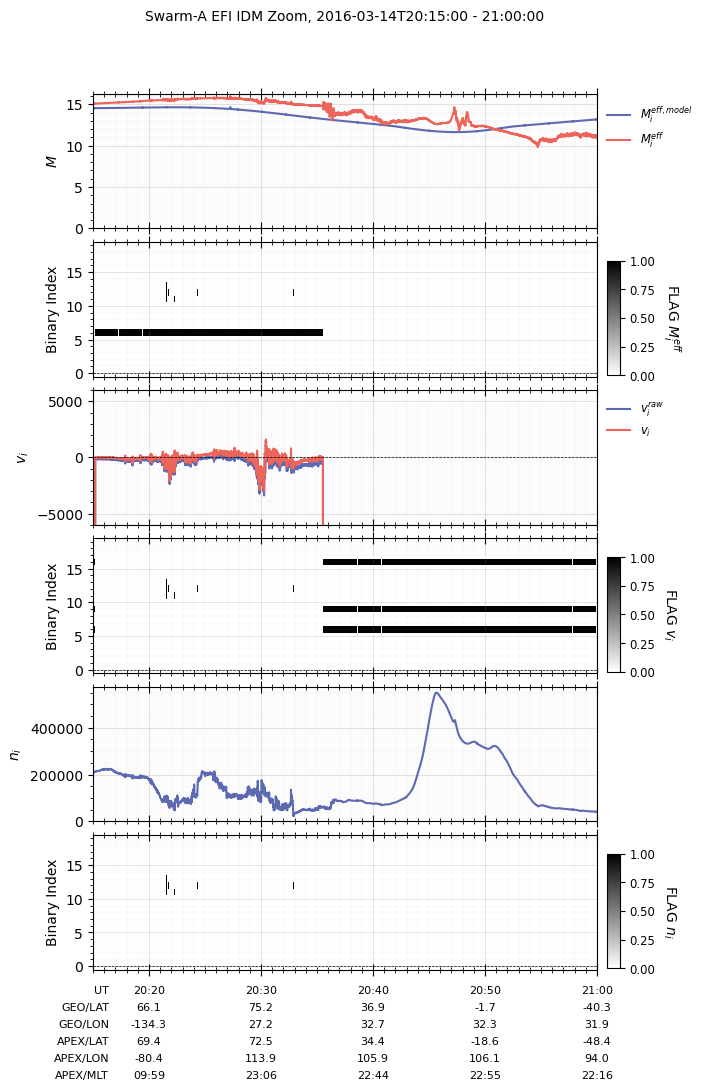

In [3]:
def test_swarm_EFI_IDM_zoom():
    """Test Swarm EFI IDM data product
    
    """
    dt_fr = datetime.datetime(2016, 3, 14, 20, 15)
    dt_to = datetime.datetime(2016, 3, 14, 21, 0)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'advanced', 'efi_idm'], sat_id='A', add_APEX=True,)

    panel_layouts = [
        [ds['M_i_eff_model'], ds['M_i_eff']],
        [ds['FLAG_M_i_eff_BIN_AUX']],
        [ds['v_i_raw'], ds['v_i']],
        [ds['FLAG_v_i_BIN_AUX']],
        [ds['n_i'],],
        [ds['FLAG_n_i_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} EFI IDM Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(file_dir=file_dir_figure, file_name='example_EFI_IDM_Swarm-{}_zoom'.format(ds.sat_id), dpi=100, append_time=False)
    db.show()
test_swarm_EFI_IDM_zoom() 